In [4]:
%pip install pandas numpy matplotlib pyarrow filesplit jupyter


import os
import glob
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Funkcja do czytelnego formatowania rozmiaru pamięci
def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

# Dekorator do pomiaru czasu wykonania funkcji
def count_time(func):
    def wrapper(*args, **kwargs):
        start = datetime.now()
        result = func(*args, **kwargs)
        duration = (datetime.now() - start).total_seconds()
        print(f"Czas wykonania {func.__name__}: {duration:.4f} s")
        return result, duration
    return wrapper

  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached filesplit-4.1.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp314-cp314-win_amd64.whl.metadata (132 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook-7.6.3-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ZAD 1

In [ ]:
def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

parquet_files = glob.glob('pliki')
print(f"Liczba znalezionych plików: {len(parquet_files)}")

dfs = [pd.read_parquet(f) for f in parquet_files]
df_orig = pd.concat(dfs, ignore_index=True)

print("\n--- Informacje o ramce danych ---")
df_orig.info(memory_usage='deep')

print("\n--- Zużycie RAM przez poszczególne kolumny ---")
for col in df_orig.columns:
    col_size = df_orig[col].memory_usage(deep=True)
    print(f"{col}: {sizeof_fmt(col_size)}")

orig_bytes = sum(df_orig.memory_usage(deep=True))
print(f"\nCałkowity rozmiar ramki w RAM: {sizeof_fmt(orig_bytes)}")

Liczba znalezionych plików: 1

--- Informacje o ramce danych ---
<class 'pandas.DataFrame'>
RangeIndex: 6884148 entries, 0 to 6884147
Data columns (total 17 columns):
 #   Column               Dtype
---  ------               -----
 0   sid                  int64
 1   sid_profile          int64
 2   post_id              str  
 3   profile_id           int64
 4   date                 str  
 5   post_type            int64
 6   description          str  
 7   likes                int64
 8   comments             int64
 9   username             str  
 10  bio                  str  
 11  following            int64
 12  followers            int64
 13  num_posts            int64
 14  is_business_account  bool 
 15  lang                 str  
 16  category             str  
dtypes: bool(1), int64(9), str(7)
memory usage: 2.9 GB

--- Zużycie RAM przez poszczególne kolumny ---
sid: 52.5MiB
sid_profile: 52.5MiB
post_id: 124.7MiB
profile_id: 52.5MiB
date: 177.3MiB
post_type: 52.5MiB
description: 1.2

ZAD 2

Rozmiar przed optymalizacją: 2.9GiB
Rozmiar po optymalizacji:    1.7GiB
Oszczędność pamięci RAM:    40.51%


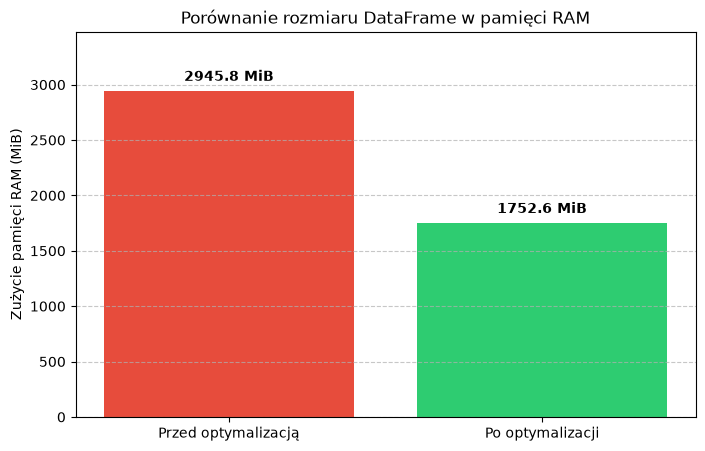

In [8]:
df_opt = df_orig.copy()


for col in df_opt.select_dtypes(include=['object', 'string']).columns:
    if df_opt[col].nunique() / len(df_opt) < 0.5:
        df_opt[col] = df_opt[col].astype('category')

for col in df_opt.select_dtypes(include=['int64', 'int32']).columns:
    df_opt[col] = pd.to_numeric(df_opt[col], downcast='integer')

for col in df_opt.select_dtypes(include=['float64']).columns:
    df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')

for col in df_opt.columns:
    if any(k in col.lower() for k in ['date', 'time', 'timestamp', 'created']):
        if df_opt[col].dtype != 'datetime64[ns]':
            df_opt[col] = pd.to_datetime(df_opt[col])

orig_bytes = sum(df_orig.memory_usage(deep=True))
opt_bytes = sum(df_opt.memory_usage(deep=True))

print(f"Rozmiar przed optymalizacją: {sizeof_fmt(orig_bytes)}")
print(f"Rozmiar po optymalizacji:    {sizeof_fmt(opt_bytes)}")
oszczednosc = ((orig_bytes - opt_bytes) / orig_bytes) * 100
print(f"Oszczędność pamięci RAM:    {oszczednosc:.2f}%")

orig_mib = orig_bytes / (1024 ** 2)
opt_mib = opt_bytes / (1024 ** 2)

plt.figure(figsize=(8, 5))
bars = plt.bar(['Przed optymalizacją', 'Po optymalizacji'], [orig_mib, opt_mib], color=['#e74c3c', '#2ecc71'])
plt.ylabel('Zużycie pamięci RAM (MiB)')
plt.title('Porównanie rozmiaru DataFrame w pamięci RAM')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + (orig_mib * 0.02), f'{yval:.1f} MiB', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, orig_mib * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

ZAD 3

In [10]:
col_cat = df_opt.select_dtypes(include=['category', 'object']).columns[0]
col_num = df_opt.select_dtypes(include=['number']).columns[0]

def operacja_grupowanie(df):
    return df.groupby(col_cat, observed=False)[col_num].mean()

def operacja_filtrowanie(df):
    srednia = df[col_num].mean()
    return df[df[col_num] > srednia]

def operacja_sortowanie(df):
    return df.sort_values(by=col_num, ascending=False)

operacje = [
    ("1. Grupowanie i agregacja", operacja_grupowanie),
    ("2. Filtrowanie wierszy", operacja_filtrowanie),
    ("3. Sortowanie danych", operacja_sortowanie)
]

wyniki = []

for nazwa, func in operacje:
    t0 = time.time()
    _ = func(df_orig)
    t_orig = time.time() - t0
    
    t0 = time.time()
    _ = func(df_opt)
    t_opt = time.time() - t0
    
    przyspieszenie = ((t_orig - t_opt) / t_orig) * 100
    wyniki.append({
        "Operacja": nazwa,
        "Czas df_orig (s)": round(t_orig, 4),
        "Czas df_opt (s)": round(t_opt, 4),
        "Różnica (%)": f"{przyspieszenie:+.2f}%"
    })

df_wyniki = pd.DataFrame(wyniki)
display(df_wyniki)

F:\TEMP\ipykernel_17300\2692938328.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_cat = df_opt.select_dtypes(include=['category', 'object']).columns[0]


,Operacja,Czas df_orig (s),Czas df_opt (s),Różnica (%)
0,1. Grupowanie i agregacja,7.8840,8.3213,-5.55%
1,2. Filtrowanie wierszy,2.3718,1.4016,+40.91%
2,3. Sortowanie danych,6.2353,3.4588,+44.53%


ZAD 4

In [12]:
folder_parquet = 'pliki'
csv_filepath = 'zamowienia_instagram.csv'

sciezki_plikow = glob.glob(f'{folder_parquet}/*.parquet')

df_opt.to_csv(csv_filepath, header=True, index=False)

csv_bytes = os.path.getsize(csv_filepath)

parquet_bytes = sum(os.path.getsize(p) for p in sciezki_plikow)

print(f"\nRozmiar pliku CSV na dysku:              {sizeof_fmt(csv_bytes)}")
print(f"Suma rozmiarów plików Parquet na dysku:   {sizeof_fmt(parquet_bytes)}")
if parquet_bytes > 0:
    print(f"\nPlik CSV jest {csv_bytes / parquet_bytes:.2f}-krotnie większy niż pliki Parquet.")


Rozmiar pliku CSV na dysku:              2.4GiB
Suma rozmiarów plików Parquet na dysku:   1020.1MiB

Plik CSV jest 2.45-krotnie większy niż pliki Parquet.


ZAD 5

In [ ]:
%%writefile skrypt_zadanie5.py
import os
import pandas as pd
from datetime import datetime
from multiprocessing import Pool

CSV_FILE = 'zamowienia_instagram.csv'
SPLIT_DIR = 'data_chunks'

def count_time(func):
    def wrapper(*args, **kwargs):
        start = datetime.now()
        result = func(*args, **kwargs)
        duration = (datetime.now() - start).total_seconds()
        print(f"[{func.__name__}] Czas wykonania: {duration:.4f} s")
        return result
    return wrapper

def podziel_plik(chunksize=1_000_000):
    os.makedirs(SPLIT_DIR, exist_ok=True)
    istniejace = [f for f in os.listdir(SPLIT_DIR) if f.endswith('.csv')]
    
    if len(istniejace) == 0:
        for i, chunk in enumerate(pd.read_csv(CSV_FILE, chunksize=chunksize)):
            chunk_path = os.path.join(SPLIT_DIR, f'chunk_{i}.csv')
            chunk.to_csv(chunk_path, index=False)
    else:
        print(f"Znaleziono gotowe fragmenty plików CSV ({len(istniejace)} plików).")

def read_single_csv(filepath):
    return pd.read_csv(filepath, on_bad_lines="skip")

@count_time
def wczytaj_multiprocessing(num_proc):
    files = [os.path.join(SPLIT_DIR, f) for f in os.listdir(SPLIT_DIR) if f.endswith('.csv')]
    with Pool(processes=num_proc) as pool:
        results = pool.map(read_single_csv, files)
        results = pd.concat(results, ignore_index=True)
    return results

if __name__ == '__main__':
    
    podziel_plik(chunksize=1_000_000)

    cores = os.cpu_count() or 4
    p1 = max(1, cores - 2)
    p2 = max(1, (cores - 2) * 2)

    print(f"\nLiczba rdzeni CPU w systemie: {cores}")
    
    print(f"\n3a. Multiprocessing ({p1} procesów = liczba_rdzeni - 2):")
    df3a = wczytaj_multiprocessing(p1)

    print(f"\n3b. Multiprocessing ({p2} procesów = (liczba_rdzeni - 2) * 2):")
    df3b = wczytaj_multiprocessing(p2)

Overwriting skrypt_zadanie5.py


In [2]:
!python skrypt_zadanie5.py

Znaleziono gotowe fragmenty plików CSV (35 plików).

Liczba rdzeni CPU w systemie: 24

3a. Multiprocessing (22 procesów = liczba_rdzeni - 2):
[wczytaj_multiprocessing] Czas wykonania: 35.3834 s

3b. Multiprocessing (44 procesów = (liczba_rdzeni - 2) * 2):
[wczytaj_multiprocessing] Czas wykonania: 22.2004 s
